# Portfolio Risk Analysis Demonstration

## Overview

We will walk through the process of loading a portfolio, fetching necessary market data, performing various risk calculations (VaR, CVaR, Beta), running stress tests and scenario analyses, optimizing the portfolio, assessing the overall risk level, and generating mitigation suggestions and reports.

The core logic is encapsulated within the `risk_engine` folder.

## 1. Setup and Imports

First, we import the necessary libraries and functions from our `risk_engine`. We also configure some basic parameters, such as the paths to example portfolios and desired output locations.

In [1]:
import sys
import os
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore') #ignore warnings
backend_path = os.path.abspath(os.path.join('web_app', 'backend'))
sys.path.insert(0, backend_path)
from risk_engine.portfolio_loader import load_portfolio 
from risk_engine.config import HISTORICAL_STRESS_SCENARIOS, PROSPECTIVE_SCENARIOS
from risk_engine.mitigation import generate_mitigation_suggestions
from risk_engine.data_fetcher import fetch_stock_data, fetch_fx_rates, fetch_market_index_data
from risk_engine.calculator import (
    calculate_portfolio_returns,
    calculate_portfolio_beta,
    fit_garch_model,
    calculate_historical_var,
    calculate_historical_cvar,
    calculate_monte_carlo_var_cvar,
    optimize_portfolio,
    run_stress_test,
    run_scenario_analysis
)
from risk_engine.reporter import (
    generate_summary_report,
    generate_heatmap,
    calculate_risk_level
)

#portfolio files
portfolio_file_usd = 'web_app/backend/data/portfolio_large_cap_diversified_usd.csv'
portfolio_file_intl = 'web_app/backend/data/portfolio_global_mix.csv' # uses international stocks

portfolio_file_to_use = portfolio_file_usd
# portfolio_file_to_use = portfolio_file_intl
base_currency = 'USD' # can be USD, EUR, etc.
market_index = '^GSPC' # S&P 500; can use '^GDAXI' for DAX, '^FTSE' for FTSE 100 etc
hist_years = 15
var_confidence = 0.95 
var_horizon = 5
optimization_objective = 'max_sharpe' # 'max_sharpe' or 'min_variance'

output_report_path = f'analysis_notebook_demo_{os.path.basename(portfolio_file_to_use).split(".")[0]}_{base_currency}.txt'
output_heatmap_path = f'heatmap_notebook_demo_{os.path.basename(portfolio_file_to_use).split(".")[0]}_{base_currency}.png'

print(f"Portfolio File: {portfolio_file_to_use}")
print(f"Base Currency: {base_currency}")
print(f"Market Index: {market_index}")
print(f"History (Years): {hist_years}")
print(f"Optimization Objective: {optimization_objective}")

Portfolio File: web_app/backend/data/portfolio_large_cap_diversified_usd.csv
Base Currency: USD
Market Index: ^GSPC
History (Years): 15
Optimization Objective: max_sharpe


## 2. Load Portfolio

We begin by loading the portfolio holdings from the specified CSV file. The expected format is a CSV with columns of 'Ticker' and 'Holdings'.

In [2]:
portfolio_df = load_portfolio(portfolio_file_to_use)
display(portfolio_df)
tickers = portfolio_df['Ticker'].tolist()

Portfolio loaded successfully from web_app/backend/data/portfolio_large_cap_diversified_usd.csv.


,Ticker,Holding
0,AAPL,50
1,MSFT,30
2,JNJ,100
3,JPM,75
4,XOM,150
5,AMZN,20


## 3. Fetch Market Data

Next, we fetch the following market data using the `yfinance` package:
1.  **Historical Stock Prices:** Daily closing prices for all tickers in the portfolio.
2.  **Stock Information:** Beta (relative to a market index like S&P 500), Sector, and primary Currency for each stock. This is crucial for FX adjustments and some scenario analyses.
3.  **Foreign Exchange (FX) Rates:** If the portfolio contains stocks traded in currencies different from the `base_currency`, we fetch the necessary historical FX rates.
4.  **Market Index Data:** Historical data for the specified `market_index` needed for Beta calculation.

In [3]:
end_date = datetime(2024, 4, 28) # using a fixed end date for reproducibility
start_date = end_date - timedelta(days=hist_years * 365.25)
start_date_str = start_date.strftime('%Y-%m-%d')
end_date_str = end_date.strftime('%Y-%m-%d')

historical_prices, beta_data, sector_data, currency_data = fetch_stock_data(
    tickers=tickers,
    start_date=start_date_str,
    end_date=end_date_str
)

display(historical_prices.head())
print("\nBeta Data:")
print(beta_data)
print("\nSector Data:")
print(sector_data)
print("\nCurrency Data:")
print(currency_data)

# fetch FX rates if needed
required_fx_pairs = set()
fx_tickers = {} # map stock currency to its FX ticker vs base
if currency_data:
    for ticker, stock_currency in currency_data.items():
        stock_currency = str(stock_currency).upper() # set to uppercase
        if stock_currency != 'N/A' and stock_currency != base_currency.upper():
            pair_ticker = f"{stock_currency}{base_currency.upper()}=X"
            required_fx_pairs.add(pair_ticker)
            fx_tickers[stock_currency] = pair_ticker

fx_rates = None
if required_fx_pairs:
    fx_rates = fetch_fx_rates(
        currency_pairs=list(required_fx_pairs),
        start_date=start_date_str,
        end_date=end_date_str
    )
    display(fx_rates.head())
else:
    fx_rates = pd.DataFrame()


# market index data
market_data = fetch_market_index_data(
    index_ticker=market_index,
    start_date=start_date_str,
    end_date=end_date_str
)
display(market_data.head())

Fetching data for tickers: ['AAPL', 'AMZN', 'JNJ', 'JPM', 'MSFT', 'XOM'] from 2009-04-28 to 2024-04-28...
Fetching additional info (beta, sector, currency) for tickers: ['AAPL', 'AMZN', 'JNJ', 'JPM', 'MSFT', 'XOM']...
Data fetching process completed.


,AAPL,AMZN,JNJ,JPM,MSFT,XOM
Date,,,,,,
2009-04-28,3.728596,4.1200,31.569508,21.975525,14.731441,37.091007
2009-04-29,3.765912,3.9895,31.806345,23.108137,14.967977,37.842999
2009-04-30,3.786679,4.0260,32.635326,22.116262,14.975365,36.864304
2009-05-01,3.829110,3.9480,32.778679,21.774462,14.960585,37.605247
2009-05-04,3.974462,3.9885,33.507935,23.986086,14.923627,37.710300



Beta Data:
{'AAPL': 1.259, 'AMZN': 1.393, 'JNJ': 0.48, 'JPM': 1.005, 'MSFT': 1.0, 'XOM': 0.579}

Sector Data:
{'AAPL': 'Technology', 'AMZN': 'Consumer Cyclical', 'JNJ': 'Healthcare', 'JPM': 'Financial Services', 'MSFT': 'Technology', 'XOM': 'Energy'}

Currency Data:
{'AAPL': 'USD', 'AMZN': 'USD', 'JNJ': 'USD', 'JPM': 'USD', 'MSFT': 'USD', 'XOM': 'USD'}

Fetching market index data for: ^GSPC from 2009-04-28 to 2024-04-28...
Market index data for ^GSPC fetched successfully.


Price,^GSPC
Ticker,^GSPC
Date,
2009-04-28,855.159973
2009-04-29,873.640015
2009-04-30,872.809998
2009-05-01,877.520020
2009-05-04,907.239990


## 4. Calculate Portfolio Value and Returns

Using the fetched prices, holdings, and FX rates, we calculate the daily historical value of the portfolio in the specified `base_currency`. We also calculate the daily percentage returns. The function returns both the portfolio-level analysis DataFrame and the individual asset returns DataFrame (in base currency).

In [4]:
portfolio_analysis, asset_returns_base_ccy = calculate_portfolio_returns(
    portfolio_df,
    historical_prices,
    currency_data=currency_data,
    fx_rates=fx_rates,
    fx_tickers=fx_tickers,
    base_currency=base_currency
)

display(portfolio_analysis.tail())
display(asset_returns_base_ccy.head())

# daily returns for later use
portfolio_daily_returns = portfolio_analysis['Daily Return'].dropna()
last_portfolio_value = portfolio_analysis['Total Value'].iloc[-1] if not portfolio_analysis.empty else np.nan
print(f"\nMost Recent Portfolio Value ({base_currency}): {last_portfolio_value:,.2f}")


Calculating daily portfolio value and returns...
Portfolio value and returns calculated successfully.


,Total Value,Daily Return
Date,,
2024-04-22,69561.054306,0.009126
2024-04-23,70167.739868,0.008722
2024-04-24,70230.611725,0.000896
2024-04-25,69813.386536,-0.005941
2024-04-26,69573.683167,-0.003433


,AAPL,MSFT,JNJ,JPM,XOM,AMZN
Date,,,,,,
2009-04-28,NaN,NaN,NaN,NaN,NaN,NaN
2009-04-29,0.010008,0.016057,0.007502,0.051540,0.020274,-0.031675
2009-04-30,0.005514,0.000494,0.026063,-0.042923,-0.025862,0.009149
2009-05-01,0.011205,-0.000987,0.004393,-0.015455,0.020099,-0.019374
2009-05-04,0.037960,-0.002470,0.022248,0.101570,0.002794,0.010258



Most Recent Portfolio Value (USD): 69,573.68


## 5. Calculate Portfolio Beta

Beta measures the portfolio's sensitivity to movements in the overall market (as represented by the `market_index`). A Beta > 1 suggests higher volatility than the market, Beta < 1 suggests lower volatility. We calculate it using the covariance between portfolio returns and market index returns.

In [5]:
portfolio_beta = np.nan 
market_returns = market_data[market_index].pct_change().dropna()
portfolio_beta = calculate_portfolio_beta(portfolio_daily_returns, market_returns)


Calculating Portfolio Beta...
Calculated Portfolio Beta: 0.893


## 6. GARCH Model Fitting and Volatility Forecast

To enhance our Monte Carlo simulations, we can model the volatility of the portfolio returns using a GARCH(1,1) model. This model captures volatility clustering (periods of high/low volatility). We fit the model to the historical daily returns and forecast the next day's conditional volatility.

In [6]:
garch_forecasted_vol = np.nan 
garch_forecasted_vol = fit_garch_model(portfolio_daily_returns)


Fitting GARCH(1,1) model...
GARCH Forecasted Conditional Volatility (1-day): 0.007629


## 7. Value at Risk (VaR) and Conditional VaR (CVaR)

We calculate the 5-day 95% VaR and CVaR using two primary methods:

1.  **Historical Simulation:** Uses the actual distribution of historical portfolio returns. VaR is the Nth percentile (e.g., 5th percentile for 95% confidence) of historical returns over the horizon. CVaR is the average return below the VaR threshold.
2.  **Monte Carlo Simulation:** Simulates thousands of possible future return paths based on statistical properties (e.g., historical drift and GARCH forecasted volatility). VaR/CVaR are then derived from the distribution of simulated outcomes.

In [7]:
print("Historical Simulation:")
hist_var_pct = calculate_historical_var(
    portfolio_returns_series=portfolio_daily_returns,
    confidence_level=var_confidence,
    horizon_days=var_horizon
)
hist_cvar_pct = calculate_historical_cvar(
    portfolio_returns_series=portfolio_daily_returns,
    confidence_level=var_confidence,
    horizon_days=var_horizon
)

hist_var_amt = hist_var_pct * last_portfolio_value if not np.isnan(hist_var_pct) else np.nan
hist_cvar_amt = hist_cvar_pct * last_portfolio_value if not np.isnan(hist_cvar_pct) else np.nan

print(f"Historical VaR %: {hist_var_pct:.4f} ({hist_var_pct*100:.2f}%)\")")
print(f"Historical VaR Amount ({base_currency}): {hist_var_amt:,.2f}")
print(f"Historical CVaR %: {hist_cvar_pct:.4f} ({hist_cvar_pct*100:.2f}%)\")")
print(f"Historical CVaR Amount ({base_currency}): {hist_cvar_amt:,.2f}")

print("\nMonte Carlo Simulation (GARCH Volatility):")
mc_var_pct, mc_cvar_pct = np.nan, np.nan 

mc_var_pct, mc_cvar_pct = calculate_monte_carlo_var_cvar(
    portfolio_returns_series=portfolio_daily_returns, # used for drift
    forecasted_volatility=garch_forecasted_vol,
    confidence_level=var_confidence,
    horizon_days=var_horizon,
    num_simulations=10000
)
mc_var_amt = mc_var_pct * last_portfolio_value if not np.isnan(mc_var_pct) else np.nan
mc_cvar_amt = mc_cvar_pct * last_portfolio_value if not np.isnan(mc_cvar_pct) else np.nan

print(f"Monte Carlo VaR %: {mc_var_pct:.4f} ({mc_var_pct*100:.2f}%)\")")
print(f"Monte Carlo VaR Amount ({base_currency}): {mc_var_amt:,.2f}")
print(f"Monte Carlo CVaR %: {mc_cvar_pct:.4f} ({mc_cvar_pct*100:.2f}%)\")")
print(f"Monte Carlo CVaR Amount ({base_currency}): {mc_cvar_amt:,.2f}")

Historical Simulation:
Calculating 5-day VaR at 95.0% confidence...
Calculated VaR: -0.0356 (This represents the potential loss)
Calculating 5-day CVaR at 95.0% confidence...
Calculated CVaR: -0.0565
Historical VaR %: -0.0356 (-3.56%)")
Historical VaR Amount (USD): -2,473.81
Historical CVaR %: -0.0565 (-5.65%)")
Historical CVaR Amount (USD): -3,930.42

Monte Carlo Simulation (GARCH Volatility):

Calculating Monte Carlo VaR & CVaR (5-day, 95.0% confidence, 10000 sims)...
Monte Carlo VaR: -0.0254
Monte Carlo CVaR: -0.0322
Monte Carlo VaR %: -0.0254 (-2.54%)")
Monte Carlo VaR Amount (USD): -1,766.77
Monte Carlo CVaR %: -0.0322 (-3.22%)")
Monte Carlo CVaR Amount (USD): -2,240.33


## 8. Portfolio Optimization

Using historical asset returns (adjusted to base currency) and their covariance, we can find optimal portfolio weights based on different objectives:

1.  **Maximize Sharpe Ratio:** Aims for the highest risk-adjusted return (assuming a risk-free rate of 0 for simplicity here).
2.  **Minimize Variance:** Aims for the lowest portfolio volatility, regardless of return.

We run the optimization based on the `optimization_objective` set earlier.

In [8]:
optimal_weights = None
optimal_portfolio_metrics = {"return": np.nan, "volatility": np.nan, "sharpe": np.nan}

optimal_weights, opt_ret, opt_vol, opt_sharpe = optimize_portfolio(
    asset_returns=asset_returns_base_ccy,
    objective=optimization_objective
)

# update if weights are found
if optimal_weights is not None:
    optimal_portfolio_metrics = {
        "return": opt_ret,
        "volatility": opt_vol,
        "sharpe": opt_sharpe
    }


Optimizing portfolio for objective: max_sharpe...
Portfolio optimization successful.
Optimal Weights:
  AAPL: 34.38%
  MSFT: 19.89%
  JNJ: 23.77%
  JPM: 2.82%
  AMZN: 19.14%
Expected Annual Return: 24.29%
Expected Annual Volatility: 20.04%
Expected Sharpe Ratio: 1.212


## 9. Stress Testing (Historical Scenarios)

We simulate the portfolio's performance during significant historical market downturns defined in `risk_engine/config.py` (e.g., 2008 GFC, 2020 COVID Crash). This shows how the current portfolio might have behaved during past crises.

In [9]:
print("\nRunning Historical Stress Tests...")

stress_test_results = {} # store results dictionary {scenario_key: result_dict}

for scenario_name in HISTORICAL_STRESS_SCENARIOS.keys():
    result = run_stress_test(
        portfolio_df,
        historical_prices,
        scenario_name
    )
    stress_test_results[scenario_name] = result

    description = result.get('scenario', scenario_name) 
    impact_pct = result.get('impact_pct', np.nan)
    start_date = result.get('start', 'N/A')
    end_date = result.get('end', 'N/A')

    print(f"  Scenario: {description}")
    print(f"  Period: {start_date} to {end_date}")
    if not np.isnan(impact_pct):
        print(f"  Estimated Impact: {impact_pct:.2%}")
    else:
        # no data for period
        fail_reason = result.get('error') or result.get('warning', "N/A")
        print(f"  Estimated Impact: N/A ({fail_reason})")


Running Historical Stress Tests...

Running Stress Test: Global Financial Crisis (GFC) (2008-01-01 to 2009-03-09)...
  Scenario: Global Financial Crisis (GFC)
  Period: 2008-01-01 to 2009-03-09
  Estimated Impact: N/A (No data for period)

Running Stress Test: COVID-19 Market Crash (2020-02-19 to 2020-03-23)...
Stress test completed. Start Value: 40357.34, End Value: 27014.98, Impact: -33.06%
  Scenario: COVID-19 Market Crash
  Period: 2020-02-19 to 2020-03-23
  Estimated Impact: -33.06%

Running Stress Test: Dot-com Bubble Burst (2000-03-10 to 2002-10-09)...
  Scenario: Dot-com Bubble Burst
  Period: 2000-03-10 to 2002-10-09
  Estimated Impact: N/A (No data for period)

Running Stress Test: 2011 US Debt Ceiling Crisis (2011-05-01 to 2011-10-04)...
Stress test completed. Start Value: 15620.15, End Value: 13582.72, Impact: -13.04%
  Scenario: 2011 US Debt Ceiling Crisis
  Period: 2011-05-01 to 2011-10-04
  Estimated Impact: -13.04%


## 10. Scenario Analysis (Prospective Scenarios)

We analyze the portfolio's potential reaction to hypothetical future market events defined in `risk_engine/config.py`. These can include interest rate shocks, broad market index drops (leveraging calculated Beta), or sector-specific downturns (using fetched sector data).

In [10]:
latest_prices = historical_prices.iloc[-1] # get last row as a series
scenario_analysis_results = {}

#loop through all scenarios
for scenario_key in PROSPECTIVE_SCENARIOS.keys():
    result_dict = run_scenario_analysis(
        portfolio_df,
        latest_prices,
        beta_data,
        sector_data,
        scenario_key
    )

    scenario_analysis_results[scenario_key] = result_dict

    description = result_dict.get('scenario', scenario_key)
    impact_pct = result_dict.get('impact_pct', np.nan)
    warning_msg = result_dict.get('warning', None)
    print(f"  Scenario: {description}")
    print(f"  Estimated Impact: {impact_pct:.2%}")
    if warning_msg:
        print(f"  Warning: {warning_msg}")


Running Scenario Analysis: +2% Interest Rate Shock...
Scenario analysis completed. Initial Value: 69573.68, Stressed Value: 66095.00, Impact: -5.00%
  Scenario: +2% Interest Rate Shock
  Estimated Impact: -5.00%

Running Scenario Analysis: -10% Major Index Drop...
Scenario analysis completed. Initial Value: 69573.68, Stressed Value: 63706.73, Impact: -8.43%
  Scenario: -10% Major Index Drop
  Estimated Impact: -8.43%

Running Scenario Analysis: -15% Technology Sector Downturn...
Scenario analysis completed. Initial Value: 69573.68, Stressed Value: 66495.31, Impact: -4.42%
  Scenario: -15% Technology Sector Downturn
  Estimated Impact: -4.42%

Running Scenario Analysis: -12% Financial Sector Downturn...
Scenario analysis completed. Initial Value: 69573.68, Stressed Value: 67871.74, Impact: -2.45%
  Scenario: -12% Financial Sector Downturn
  Estimated Impact: -2.45%

Running Scenario Analysis: +30% Oil Price Shock...
Scenario analysis completed. Initial Value: 69573.68, Stressed Value: 

## 11. Overall Risk Assessment and Heatmap

Based on configurable thresholds (defined in `risk_engine/config.py`) applied to key results (e.g., VaR, historical stress tests, specific prospective scenarios like Index Drop), we determine an overall risk level (Low, Moderate, High) for the portfolio. A visual heatmap summarizes this assessment.


Overall Risk Level: Moderate
Rationale:
- Overall risk assessed as Moderate.
- Worst stress test (COVID-19 Market Crash: -33.06%) exceeds Yellow threshold (-25.0%)
- Prospective Index Drop scenario result unavailable.

Generating Risk Heatmap...
Assessed Risk Level: Moderate Risk
Heatmap saved to heatmap_notebook_demo_portfolio_large_cap_diversified_usd_USD.png


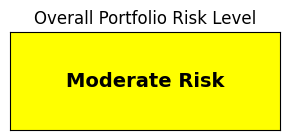

In [11]:
#initialize
risk_level = 'Unknown'
risk_rationale = ['Risk level calculation pending.']

var_arg = hist_var_pct
stress_arg = list(stress_test_results.values())
scenario_arg = list(scenario_analysis_results.values())
risk_level, risk_rationale = calculate_risk_level(
    var_arg,
    stress_arg,
    scenario_arg
)

print(f"\nOverall Risk Level: {risk_level}")
print("Rationale:")
for reason in risk_rationale:
    print(f"- {reason}")

generate_heatmap(risk_level, output_heatmap_path)
from IPython.display import Image, display
display(Image(filename=output_heatmap_path))

## 12. Risk Mitigation Suggestions

If the overall risk level is determined to be 'Moderate' or 'High', the system provides rule-based suggestions for mitigating the risk. These suggestions might point towards concentration issues, high beta exposure, or general diversification needs, based on the portfolio composition and risk drivers.

In [12]:
mitigation_suggestions = generate_mitigation_suggestions(
    portfolio_df=portfolio_df,
    latest_prices=latest_prices,
    beta_data=beta_data,
    risk_level=risk_level,
    risk_rationale=risk_rationale
)
print("\nRisk Mitigation Suggestions:")
for suggestion in mitigation_suggestions:
    print(f"- {suggestion}")


Risk Mitigation Suggestions:
- Risk Level is Moderate. Specific factors contributing to review:
-  - Moderate Stress Test Performance: Review concentration (Top: XOM (24.6%), JPM (20.4%), JNJ (20.4%)) and market sensitivity (Beta: 0.84) in light of historical downturns.
-  - Moderate Sensitivity to Index Drops: Review exposure to high beta stocks (Top: AMZN (Beta: 1.39), AAPL (Beta: 1.26), JPM (Beta: 1.00)). Consider if >1.0 is appropriate.
- Consider targeted adjustments (e.g., slight rebalancing, reviewing specific high-beta/volatile positions) if these factors align negatively with your market outlook.


## 13. Summary Report

Finally, we compile all the calculated metrics, test results, risk assessment, and mitigation suggestions into a comprehensive text report.

In [13]:
# prepare arguments for report
stress_report_arg = list(stress_test_results.values())
scenario_report_arg = list(scenario_analysis_results.values())
report_data = {
    "portfolio_file": portfolio_file_to_use,
    "base_currency": base_currency,
    "market_index": market_index,
    "analysis_period_start": start_date_str,
    "analysis_period_end": end_date_str,
    "last_portfolio_value": last_portfolio_value,
    "portfolio_beta": portfolio_beta,
    "garch_volatility": garch_forecasted_vol,
    "var_pct": hist_var_pct, # key expected by reporter
    "var_amount": hist_var_amt,
    "cvar_pct": hist_cvar_pct,
    "cvar_amount": hist_cvar_amt,
    "mc_var_pct": mc_var_pct,
    "mc_var_amount": mc_var_amt,
    "mc_cvar_pct": mc_cvar_pct,
    "mc_cvar_amount": mc_cvar_amt,
    "optimization_objective": optimization_objective,
    "optimal_weights": optimal_weights,
    "optimal_portfolio_metrics": optimal_portfolio_metrics,
    "stress_tests": stress_report_arg,
    "scenario_analysis": scenario_report_arg,
    "risk_level": risk_level,
    "portfolio_df": portfolio_df,
    "beta_data": beta_data,
    "latest_prices": latest_prices, 
    "var_confidence": var_confidence,
    "var_horizon": var_horizon,
    "analysis_date": datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    # risk_rationale is calculated internally
}
generate_summary_report(report_data, output_report_path)
with open(output_report_path, 'r') as f_read:
    report_content_from_file = f_read.read()
print(report_content_from_file)
print("--- End of Report ---")


Generating summary report to analysis_notebook_demo_portfolio_large_cap_diversified_usd_USD.txt...
Summary report generated successfully.
========== Portfolio Risk Analysis Summary ==========
Portfolio File: web_app/backend/data/portfolio_large_cap_diversified_usd.csv
Analysis Date: 2025-05-01 02:00:31
Reporting Currency: USD

Overall Risk Level: Moderate
Rationale:
- ['Overall risk assessed as Moderate.', 'Worst stress test (COVID-19 Market Crash: -33.06%) exceeds Yellow threshold (-25.0%)', 'Prospective Index Drop scenario result unavailable.']

--- Value at Risk & CVaR (5-Day, 95% Confidence) ---
-> VaR Return: -3.56%
-> VaR Amount: $-2,473.81
-> CVaR Return (Expected Shortfall): -5.65%
-> CVaR Amount: $-3,930.42

--- Monte Carlo VaR & CVaR (5-Day, 95% Confidence) ---
(Based on GARCH Volatility Forecast: 0.007629)
-> MC VaR Return: -2.54%
-> MC VaR Amount: $-1,766.77
-> MC CVaR Return: -3.22%
-> MC CVaR Amount: $-2,240.33

--- Portfolio Beta (vs Market) ---
-> Beta: 0.893

--- Hist